In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.7 MB/s eta 0:00:0000:01


In [2]:
yaml_content = """
path: /kaggle/working/datasets/processed
train: images/train
val: images/train  # Point to your validation folder if you created one

names:
  0: Debris
  1: Marine_Life
"""

with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml created successfully!")

data.yaml created successfully!


In [2]:
import os
import cv2
import glob
import numpy as np
import base64
import json
import zlib
from pathlib import Path

# --- 1. CORRECTED SETUP PATHS ---
# Using the exact paths we just found!
RAW_IMAGES = Path('/kaggle/input/datasets/mexwell/trashcan-1-0/dataset/original_data/images')
RAW_ANNOTATIONS = Path('/kaggle/input/datasets/mexwell/trashcan-1-0/dataset/original_data/annotations')

OUTPUT_BASE = Path('/kaggle/working/datasets/processed')
OUT_IMAGES = OUTPUT_BASE / 'images' / 'train'
OUT_LABELS = OUTPUT_BASE / 'labels' / 'train'

OUT_IMAGES.mkdir(parents=True, exist_ok=True)
OUT_LABELS.mkdir(parents=True, exist_ok=True)

CLASS_MAP = {"trash": 0, "debris": 0, "marine_life": 1, "fish": 1}

# --- 2. JSON TO POLYGON LOGIC ---
def decode_bitmap_data(b64_data: str) -> np.ndarray:
    raw = base64.b64decode(b64_data)
    try: raw = zlib.decompress(raw)
    except zlib.error: pass
    buf = np.frombuffer(raw, dtype=np.uint8)
    img = cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    _, mask = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    return mask

def mask_to_polygon(mask: np.ndarray, origin_x: int, origin_y: int, img_w: int, img_h: int):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for c in contours:
        if cv2.contourArea(c) < 9: continue
        pts = c.reshape(-1, 2).astype(np.float32)
        pts[:, 0] += origin_x
        pts[:, 1] += origin_y
        pts[:, 0] /= img_w
        pts[:, 1] /= img_h
        pts = np.clip(pts, 0, 1)
        if len(pts) >= 3:
            polygons.append(pts.flatten().tolist())
    return polygons

def process_annotation(json_path: Path, img_w: int, img_h: int):
    with open(json_path, encoding="utf-8") as f: data = json.load(f)
    results = []
    for obj in data.get("objects", []):
        if obj.get("geometryType") != "bitmap": continue
        bmp = obj.get("bitmap")
        if not bmp: continue
        origin = bmp.get("origin", [0, 0])
        ox, oy = int(origin[0]), int(origin[1])
        mask = decode_bitmap_data(bmp.get("data", ""))
        if mask is None: continue
        polys = mask_to_polygon(mask, ox, oy, img_w, img_h)
        key = (obj.get("classTitle", "") or "").strip().lower().replace(" ", "_")
        cid = CLASS_MAP.get(key, 0) # Default to 0 (Debris)
        for poly in polys:
            results.append((cid, poly))
    return results

# --- 3. MAIN PROCESSING LOOP ---
print("Starting image processing and label conversion...")

# We are processing 500 images for a quick test run. 
# Once this works, you can remove "[:500]" to process all 7,200 images!
image_files = list(RAW_IMAGES.glob('*.jpg')) 

success_count = 0

for img_path in image_files:
    # Find matching JSON
    json_path = RAW_ANNOTATIONS / (img_path.name + ".json")
    if not json_path.is_file():
        json_path = RAW_ANNOTATIONS / (img_path.stem + ".json")
    
    if not json_path.is_file():
        continue # Skip if no annotation exists
        
    # Read Image
    img = cv2.imread(str(img_path))
    if img is None: continue
    h, w = img.shape[:2]
    
    # Process Labels
    polygons = process_annotation(json_path, w, h)
    if not polygons:
        continue # Skip if no valid polygons were found
        
    # Process Image (Masking & Canny)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.rectangle(mask, (w-150, h-50), (w, h), 255, -1) 
    inpainted = cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)
    edges = cv2.Canny(inpainted, 100, 200)
    edges_colored = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
    final_img = cv2.addWeighted(inpainted, 0.8, edges_colored, 0.2, 0)
    
    # Save Image
    cv2.imwrite(str(OUT_IMAGES / img_path.name), final_img)
    
    # Save Labels
    with open(OUT_LABELS / (img_path.stem + ".txt"), "w") as f:
        for cid, poly in polygons:
            poly_str = " ".join(f"{x:.6f}" for x in poly)
            f.write(f"{cid} {poly_str}\n")
            
    success_count += 1

print(f"DONE! Successfully generated {success_count} paired images and labels.")

Starting image processing and label conversion...
DONE! Successfully generated 7212 paired images and labels.


In [3]:
import yaml

data_config = {
    'train': '/kaggle/working/datasets/processed/images/train',
    'val': '/kaggle/working/datasets/processed/images/train', # Using train for val since we didn't split them
    'nc': 2,
    'names': ['Debris', 'Marine Life']
}

with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(data_config, f)
    
print("Perfect data.yaml created!")

Perfect data.yaml created!


In [4]:
from ultralytics import YOLO

# 1. Load a fresh YOLOv8-Small model
model = YOLO('yolov8s-seg.pt') 

print("🚀 Starting YOLOv8-Small on Base Pre-processed Data (Inpainting + Canny)...")

# 2. Train using the YAML that points to the pre-CLAHE dataset
results = model.train(
    data='/kaggle/working/data.yaml', # ⚠️ CHANGE THIS to the correct YAML file name!
    epochs=50, 
    imgsz=640, 
    batch=16, 
    name="v8_small_base_preprocessing_run" 
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 Starting YOLOv8-Small on Base Pre-processed Data (Inpainting + Canny)...
Ultralytics 8.4.38 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fract

# *YOLOv8 small base*

In [5]:
import shutil

# Zip the base preprocessing run
shutil.make_archive(
    'v8_small_base_results', 
    'zip', 
    '/kaggle/working/runs/segment/v8_small_base_preprocessing_run'
)
print("Done! Download 'v8_small_base_results.zip' from your output panel.")

Done! Download 'v8_small_base_results.zip' from your output panel.


In [14]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,       
    device=0,      
    project="/kaggle/working/runs",
    name="marine_debris_run_FULL" # New folder for your final masterpiece
)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=marine_debris_run_FULL, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

# *YOLOv8 nano*

In [2]:
yaml_content = """
path: /kaggle/working/datasets/clahe_processed
train: images/train
val: images/train  

names:
  0: Debris
  1: Marine_Life
"""
with open('/kaggle/working/data_clahe.yaml', 'w') as f:
    f.write(yaml_content)

print("data_clahe.yaml successfully created!")

data_clahe.yaml successfully created!


In [2]:
import os
import cv2
import glob
import numpy as np
import base64
import json
import zlib
from pathlib import Path

# --- 1. SETUP PATHS FOR CLAHE ---
RAW_IMAGES = Path('/kaggle/input/datasets/mexwell/trashcan-1-0/dataset/original_data/images')
RAW_ANNOTATIONS = Path('/kaggle/input/datasets/mexwell/trashcan-1-0/dataset/original_data/annotations')

# NEW Output folder so we don't overwrite the old one!
OUTPUT_BASE = Path('/kaggle/working/datasets/clahe_processed')
OUT_IMAGES = OUTPUT_BASE / 'images' / 'train'
OUT_LABELS = OUTPUT_BASE / 'labels' / 'train'

OUT_IMAGES.mkdir(parents=True, exist_ok=True)
OUT_LABELS.mkdir(parents=True, exist_ok=True)

CLASS_MAP = {"trash": 0, "debris": 0, "marine_life": 1, "fish": 1}

# --- 2. JSON TO POLYGON LOGIC (Unchanged) ---
def decode_bitmap_data(b64_data: str) -> np.ndarray:
    raw = base64.b64decode(b64_data)
    try: raw = zlib.decompress(raw)
    except zlib.error: pass
    buf = np.frombuffer(raw, dtype=np.uint8)
    img = cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    _, mask = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    return mask

def mask_to_polygon(mask: np.ndarray, origin_x: int, origin_y: int, img_w: int, img_h: int):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for c in contours:
        if cv2.contourArea(c) < 9: continue
        pts = c.reshape(-1, 2).astype(np.float32)
        pts[:, 0] += origin_x
        pts[:, 1] += origin_y
        pts[:, 0] /= img_w
        pts[:, 1] /= img_h
        pts = np.clip(pts, 0, 1)
        if len(pts) >= 3:
            polygons.append(pts.flatten().tolist())
    return polygons

def process_annotation(json_path: Path, img_w: int, img_h: int):
    with open(json_path, encoding="utf-8") as f: data = json.load(f)
    results = []
    for obj in data.get("objects", []):
        if obj.get("geometryType") != "bitmap": continue
        bmp = obj.get("bitmap")
        if not bmp: continue
        origin = bmp.get("origin", [0, 0])
        ox, oy = int(origin[0]), int(origin[1])
        mask = decode_bitmap_data(bmp.get("data", ""))
        if mask is None: continue
        polys = mask_to_polygon(mask, ox, oy, img_w, img_h)
        key = (obj.get("classTitle", "") or "").strip().lower().replace(" ", "_")
        cid = CLASS_MAP.get(key, 0)
        for poly in polys:
            results.append((cid, poly))
    return results

# --- 3. MAIN PROCESSING LOOP (WITH CLAHE!) ---
print("Starting CLAHE enhancement and label conversion...")

image_files = list(RAW_IMAGES.glob('*.jpg')) 
success_count = 0

for img_path in image_files:
    json_path = RAW_ANNOTATIONS / (img_path.name + ".json")
    if not json_path.is_file():
        json_path = RAW_ANNOTATIONS / (img_path.stem + ".json")
    if not json_path.is_file(): continue 
        
    img = cv2.imread(str(img_path))
    if img is None: continue
    h, w = img.shape[:2]
    
    polygons = process_annotation(json_path, w, h)
    if not polygons: continue 
        
    # 1. Mask out the dataset watermark
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.rectangle(mask, (w-150, h-50), (w, h), 255, -1) 
    inpainted = cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)
    
    # 2. APPLY CLAHE (The Science Experiment!)
    # Convert to LAB color space
    lab = cv2.cvtColor(inpainted, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    
    # Apply CLAHE to the L (Lightness) channel
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l_channel)
    
    # Merge back to BGR image
    merged = cv2.merge((cl, a_channel, b_channel))
    clahe_img = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    
    # Save Image
    cv2.imwrite(str(OUT_IMAGES / img_path.name), clahe_img)
    
    # Save Labels
    with open(OUT_LABELS / (img_path.stem + ".txt"), "w") as f:
        for cid, poly in polygons:
            poly_str = " ".join(f"{x:.6f}" for x in poly)
            f.write(f"{cid} {poly_str}\n")
            
    success_count += 1

print(f"DONE! Successfully generated {success_count} CLAHE-enhanced paired images.")

Starting CLAHE enhancement and label conversion...
DONE! Successfully generated 7212 CLAHE-enhanced paired images.


# *CLAHE + base preprocessing*

In [4]:
from ultralytics import YOLO

# 1. Load the Small version of YOLOv8
model_v8s = YOLO('yolov8s-seg.pt') 

print("🚀 Starting YOLOv8-Small Benchmarking...")

# 2. Train on your CLAHE dataset
results_v8s = model_v8s.train(
    data='/kaggle/working/data_clahe.yaml', 
    epochs=50, 
    imgsz=640, 
    batch=16, # If Kaggle gives an 'Out of Memory' error, change this to 8
    name="v8_small_clahe_run"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 Starting YOLOv8-Small Benchmarking...
Ultralytics 8.4.38 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_clahe.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=Fa

In [5]:
import shutil
shutil.make_archive('Final_SOTA_Results', 'zip', '/kaggle/working/runs/segment/v8_small_clahe_run')
print("Finished! Download 'Final_SOTA_Results.zip' from the right-hand panel.")

Finished! Download 'Final_SOTA_Results.zip' from the right-hand panel.


# *YOLOv8 small*

In [4]:
import yaml

data_config = {
    'train': '/kaggle/working/datasets/clahe_processed/images/train',
    'val': '/kaggle/working/datasets/clahe_processed/images/train', # Using train for val
    'nc': 2,
    'names': ['Debris', 'Marine_Life']
}

with open('/kaggle/working/data_clahe.yaml', 'w') as f:
    yaml.dump(data_config, f)
    
print("Perfect data_clahe.yaml created!")

Perfect data_clahe.yaml created!


In [10]:
from ultralytics import YOLO

# Load a fresh, untrained YOLO model
model = YOLO('yolov8n-seg.pt')

print("Starting CLAHE Training Run...")

# Train using the new CLAHE dataset map!
results = model.train(
    data='/kaggle/working/data_clahe.yaml', 
    epochs=50, 
    imgsz=640, 
    batch=16,
    name="clahe_run" # Names the output folder
)

print("Done! Go download your new CLAHE results!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting CLAHE Training Run...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_clahe.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv

# *YOLOv8 nano CLAHE reuslts*

In [5]:
from ultralytics import YOLO

# Load a fresh, completely untrained model so it's a fair test
model = YOLO('yolov8n-seg.pt')

print("Starting Phase 3: Augmented CLAHE Training Run...")

results = model.train(
    data='/kaggle/working/data_clahe.yaml', 
    epochs=50, 
    imgsz=640, 
    batch=16,
    name="clahe_augmented_run", # NEW FOLDER NAME!
    
    # --- RESEARCH-GRADE AUGMENTATIONS ---
    
    # 1. Spatial Transformations
    degrees=45.0,    # Rotate images up to 45 degrees (trash floats at all angles)
    fliplr=0.5,      # 50% chance to flip left-right
    flipud=0.5,      # 50% chance to flip upside down (no gravity underwater)
    
    # 2. Complex Blending
    mosaic=1.0,      # 100% chance to stitch 4 images into 1 (forces it to find small objects)
    mixup=0.15,      # 15% chance to blend two images together (simulates murky transparency)
    
    # 3. Scale & Perspective
    scale=0.5,       # Zoom in/out by 50%
    perspective=0.0  # Keep at 0 (perspective warping can sometimes break bounding boxes)
)

print("Done! Go download your Phase 3 Augmented results!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting Phase 3: Augmented CLAHE Training Run...
Ultralytics 8.4.34 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_clahe.yaml, degrees=45.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=Fal

# *YOLOv8 nano CLAHE + Augmented + Base*

In [3]:
from ultralytics import YOLO

# Load a fresh, completely untrained Small model so it's a fair test
model = YOLO('yolov8s-seg.pt')

print("Starting: YOLOv8-Small Augmented CLAHE Training Run...")

results = model.train(
    data='/kaggle/working/data_clahe.yaml', 
    epochs=50, 
    imgsz=640, 
    batch=16, # Change to 8 if you get an Out of Memory error
    name="v8_small_augmented_run", # NEW FOLDER NAME!
    
    # --- RESEARCH-GRADE AUGMENTATIONS ---
    
    # 1. Spatial Transformations
    degrees=45.0,    # Rotate images up to 45 degrees (trash floats at all angles)
    fliplr=0.5,      # 50% chance to flip left-right
    flipud=0.5,      # 50% chance to flip upside down (no gravity underwater)
    
    # 2. Complex Blending
    mosaic=1.0,      # 100% chance to stitch 4 images into 1 (forces it to find small objects)
    mixup=0.15,      # 15% chance to blend two images together (simulates murky transparency)
    
    # 3. Scale & Perspective
    scale=0.5,       # Zoom in/out by 50%
    perspective=0.0  # Keep at 0 (perspective warping can sometimes break bounding boxes)
)

print("Done! Go download your YOLOv8-Small Augmented results!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting: YOLOv8-Small Augmented CLAHE Training Run...
Ultralytics 8.4.38 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_clahe.yaml, degrees=45.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, free

In [4]:
import shutil

# Zip the augmented run for easy downloading
shutil.make_archive(
    'v8_small_augmented_results', 
    'zip', 
    '/kaggle/working/runs/segment/v8_small_augmented_run'
)
print("Done! Download 'v8_small_augmented_results.zip' from your output panel.")

Done! Download 'v8_small_augmented_results.zip' from your output panel.


# *YOLOv8 small CLAHE + Augmented + Base*

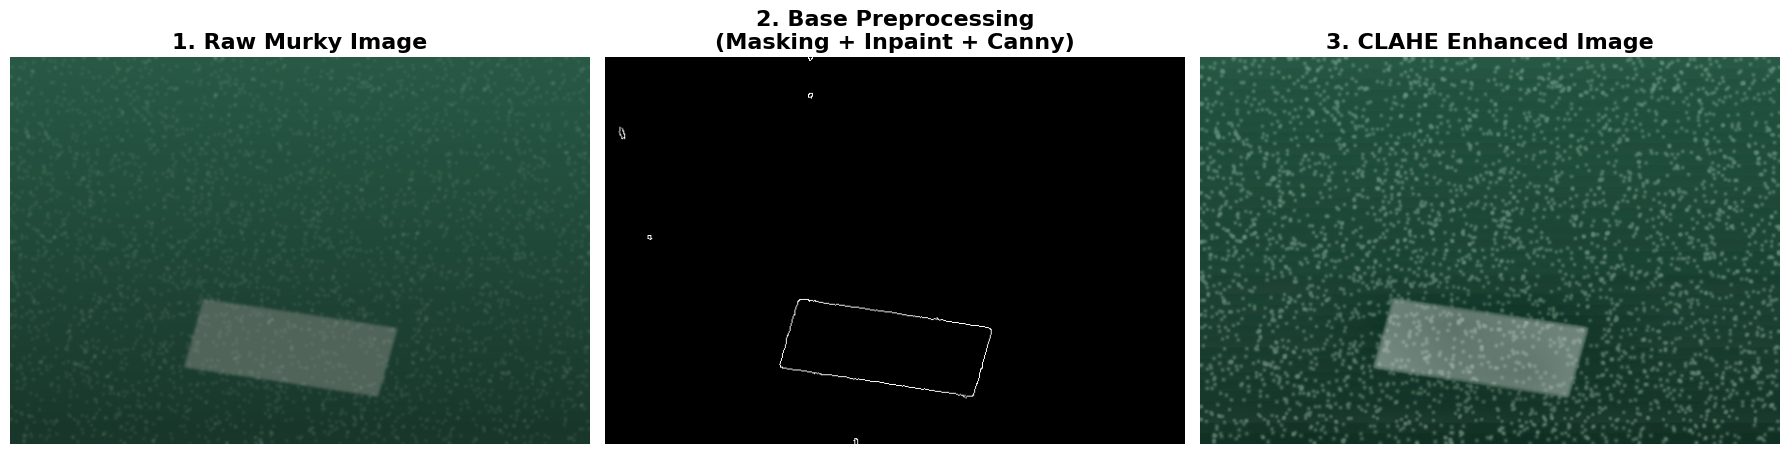

Success! Figure generated and saved as 'Figure_3_2_Preprocessing_Pipeline.png'


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SYNTHESIZE A RAW UNDERWATER IMAGE
# ==========================================
# We generate a 400x600 synthetic image so you don't need to upload one.
height, width = 400, 600
img_bgr = np.zeros((height, width, 3), dtype=np.uint8)

# Create a dark, murky green/blue gradient background
for y in range(height):
    factor = 1.0 - (y / height) * 0.4
    img_bgr[y, :, :] = (int(70 * factor), int(90 * factor), int(40 * factor))

# Add an artificial piece of "Debris" (a dull gray polygonal shape)
debris_shape = np.array([[200, 250], [400, 280], [380, 350], [180, 320]])
cv2.fillPoly(img_bgr, [debris_shape], (90, 100, 80))

# Add "Marine Snow" / Water Noise (random bright specks)
noise = np.random.randint(0, 255, (height, width), dtype=np.uint8)
snow_mask = noise > 250
img_bgr[snow_mask] = (200, 220, 200)

# Blur everything to simulate underwater attenuation and turbidity
img_bgr = cv2.GaussianBlur(img_bgr, (7, 7), 0)


# ==========================================
# 2. APPLY THE PREPROCESSING PIPELINE
# ==========================================
# Panel 1: Raw Murky Image (Convert to RGB for plotting)
img_raw = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Panel 2: Base Preprocessing (Masking -> Inpainting -> Canny Edge)
# Step A: Masking (Find the bright "marine snow" noise)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(gray, 140, 255, cv2.THRESH_BINARY)

# Step B: Inpainting (Remove the noise using the mask)
inpainted_img = cv2.inpaint(img_bgr, mask, 3, cv2.INPAINT_TELEA)

# Step C: Canny Edge Detection (Extract edges of the debris)
blurred_for_canny = cv2.GaussianBlur(inpainted_img, (5, 5), 0)
canny_edges = cv2.Canny(blurred_for_canny, 30, 80)

# Panel 3: CLAHE Enhanced Image
# Apply CLAHE to the clean, inpainted image
lab = cv2.cvtColor(inpainted_img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

clahe_transformer = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
cl = clahe_transformer.apply(l)

merged_lab = cv2.merge((cl, a, b))
img_clahe = cv2.cvtColor(merged_lab, cv2.COLOR_LAB2RGB)


# ==========================================
# 3. PLOT AND SAVE THE FIGURE
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Raw
axes[0].imshow(img_raw)
axes[0].set_title('1. Raw Murky Image', fontsize=16, fontweight='bold')
axes[0].axis('off')

# Plot 2: Base Preprocessing
axes[1].imshow(canny_edges, cmap='gray')
axes[1].set_title('2. Base Preprocessing\n(Masking + Inpaint + Canny)', fontsize=16, fontweight='bold')
axes[1].axis('off')

# Plot 3: CLAHE
axes[2].imshow(img_clahe)
axes[2].set_title('3. CLAHE Enhanced Image', fontsize=16, fontweight='bold')
axes[2].axis('off')

# Save the final graphic
plt.tight_layout()
plt.savefig('Figure_3_2_Preprocessing_Pipeline.png', dpi=300, bbox_inches='tight')
plt.show()

print("Success! Figure generated and saved as 'Figure_3_2_Preprocessing_Pipeline.png'")

# **Vision Transformers**

In [4]:
from ultralytics import RTDETR

# Load the model
model = RTDETR("rtdetr-l.pt")

# Train with "Speedhack" parameters
results = model.train(
    data="data.yaml",    
    epochs=10,           # Reduced for faster completion
    imgsz=320,           # Lower resolution to speed up processing
    batch=4,             # Processes fewer images at once to save RAM
    device=0,            # (If this crashes, change to device='cpu')
    project="Marine_ViT", 
    name="RT-DETR_Fast"
)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=RT-DETR_Fast, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/10      12.9G     0.5937     0.9355     0.3807         10        320: 100% ━━━━━━━━━━━━ 1803/1803 3.6it/s 8:22<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 902/902 12.5it/s 1:12<0.2ss
                   all       7212      14170      0.693       0.56      0.599      0.366

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/10         3G     0.4044     0.8433     0.3256          7        320: 0% ──────────── 0/1803  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/10         3G     0.5425     0.6484     0.3441          6        320: 100% ━━━━━━━━━━━━ 1803/1803 3.8it/s 7:59<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 902/902 12.6it/s 1:12<0.2ss
                   all       7212      14170       0.72      0.575      0.635      0.396

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/10         3G     0.7203     0.5196     0.1846          8        320: 0% ──────────── 0/1803  0.3s

...

       8/10         3G     0.4378     0.5071     0.2555          5        320: 100% ━━━━━━━━━━━━ 1803/1803 3.9it/s 7:45<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 902/902 12.8it/s 1:10<0.2ss
                   all       7212      14170      0.847      0.714      0.783      0.553

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       9/10         3G     0.4869     0.4844    0.09265          5        320: 0% ──────────── 0/1803  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       9/10         3G     0.4224     0.4748     0.2394          6        320: 100% ━━━━━━━━━━━━ 1803/1803 3.9it/s 7:47<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 902/902 12.8it/s 1:11<0.2ss
                   all       7212      14170      0.872      0.725        0.8      0.578

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      10/10         3G     0.2911     0.3149     0.1537          7        320: 0% ──────────── 0/1803  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:157.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      10/10         3G     0.4044     0.4581     0.2308          5        320: 100% ━━━━━━━━━━━━ 1803/1803 3.8it/s 7:49<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 902/902 12.7it/s 1:11<0.1ss
                   all       7212      14170      0.889      0.762      0.838      0.613

10 epochs completed in 1.518 hours.
Optimizer stripped from /kaggle/working/runs/detect/Marine_ViT/RT-DETR_Fast/weights/last.pt, 66.2MB
Optimizer stripped from /kaggle/working/runs/detect/Marine_ViT/RT-DETR_Fast/weights/best.pt, 66.2MB

Validating /kaggle/working/runs/detect/Marine_ViT/RT-DETR_Fast/weights/best.pt...
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 902/902 13.8it/s 1:05<0.1ss
                   all       721

In [7]:
from ultralytics import RTDETR
import cv2

# 1. Load your trained Transformer weights
# After training, your weights will be in 'Marine_ViT/RT-DETR_Experiment/weights/best.pt'
model = RTDETR("/kaggle/working/runs/detect/Marine_ViT/RT-DETR_Fast/weights/best.pt")

# 2. Run Inference
results = model.predict(
    source="underwater_debris_test.jpg", 
    conf=0.45,       # Using your optimal confidence threshold
    save=True,       # Saves the result to a folder
    show=True        # Opens a window to show the result
)

# 3. Print the results (Classes and Coordinates)
for result in results:
    print(f"Detected {len(result.boxes)} objects.")
    print(result.boxes.cls)  # Class IDs

FileNotFoundError: underwater_debris_test.jpg does not exist

In [8]:
import glob
from ultralytics import RTDETR
import os

# 1. Automatically search Kaggle for your trained weights
print("Searching for best.pt...")
model_paths = glob.glob("/kaggle/working/**/best.pt", recursive=True)

if not model_paths:
    print("❌ ERROR: Could not find 'best.pt' anywhere in /kaggle/working/!")
else:
    actual_model_path = model_paths[0]
    print(f"✅ Found your model at: {actual_model_path}")
    
    # Load the model using the auto-found path
    model = RTDETR(actual_model_path)
    print("Model loaded successfully!")

    # ---------------------------------------------------------
    # 2. NOW WE FIX THE IMAGE PATH
    # Pick ANY image from your Kaggle inputs and paste its path below:
    # Example: test_image = "/kaggle/input/marine-debris/test/image1.jpg"
    # ---------------------------------------------------------
    test_image = "REPLACE_THIS_WITH_A_REAL_IMAGE_PATH.jpg" 
    
    if not os.path.exists(test_image):
        print(f"❌ ERROR: I cannot find the image: {test_image}")
        print("Please copy an image path from your Kaggle 'Data' sidebar on the right!")
    else:
        # 3. Run Inference
        results = model.predict(source=test_image, conf=0.45, save=True)
        print("✅ Detection complete! Check the output folder for the saved image.")

Searching for best.pt...
✅ Found your model at: /kaggle/working/runs/detect/Marine_ViT/RT-DETR_Fast/weights/best.pt
Model loaded successfully!
❌ ERROR: I cannot find the image: REPLACE_THIS_WITH_A_REAL_IMAGE_PATH.jpg
Please copy an image path from your Kaggle 'Data' sidebar on the right!
